# Setup

In [121]:
# Add parent directory to current path. Needed for research imports.
import os.path
import sys

p = os.path.abspath("../..")
if p not in sys.path:
    sys.path.insert(0, p)

# Enable hot reloading
%load_ext autoreload
%autoreload 2


import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from experiments.irl.datasets import *
from experiments.irl.experiment_utils import *
from research.irl.fair_irl import *
from research.utils import *


logging.basicConfig(level=logging.INFO)
warnings.filterwarnings("ignore")

sns.set_style("darkgrid")

from IPython.display import display, HTML

display(HTML("<style>.container { width:1800px !important; }</style>"))
pd.set_option("display.max_columns", None)
# pd.set_option('display.max_colwidth', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Run experiments

In [122]:
base_exp_info = {
    "EXPERIMENT_NAME": "thesis_7",
    "FEAT_EXP_OBJECTIVE_NAMES": [
        "Acc",
        "DemPar",
        "EqOpp",
        #         'FPRPar',
        #         'TNRPar',
        #         'FNRPar',
        #         'TPR_Z0',
        #         'TPR_Z1',
        #         'TNR_Z0',
        #         'TNR_Z1',
        #         'FPR_Z0',
        #         'FPR_Z1',
        #         'FNR_Z0',
        #         'FNR_Z1',
    ],
    "PERF_MEAS_OBJECTIVE_NAMES": [
        "Acc",
        "DemPar",
        "EqOpp",
    ],
    # Expert demo parameters
    "DATASET": "Boston",
    "TARGET_DATASET": "COMPAS",
    "N_EXPERT_DEMOS": 3,
    "EXPERT_ALGO": None,
    "N_DATASET_SAMPLES": 20_000,
    "MIN_FREQ_FILL_PCT": 0.05,
    "RESTRICT_Y_ACTION": True,
    # IRL Loop parameters
    "IRL_METHOD": None,
    "METHOD": "highs",
    # Plotting parameters
    "NOISE_FACTOR": 0.02,
    "ANNOTATE": True,
    "N_INIT_POLICIES": 3,
    "NON_EXPERT_ALGOS": [
        "OptAccNoisy",
        "HardtDemParNoisy",
        "HardtEqOppNoisy",
        #             'Dummy',
        #         'DummyNoisy',
    ],
}

In [123]:
base_exp_info["N_TRIALS"] = 24
# base_exp_info['IGNORE_RESULTS_EPSILON'] = .06
base_exp_info["EPSILON"] = 0.015
base_exp_info["IGNORE_RESULTS_EPSILON"] = np.infty
# base_exp_info['IGNORE_RESULTS_EPSILON'] = .05
base_exp_info["MAX_ITER"] = 15
base_exp_info["ALLOW_NEG_WEIGHTS"] = False
base_exp_info["DOT_WEIGHTS_FEAT_EXP"] = True
base_exp_info["IRL_ERROR_ENCOURAGE_EVEN_WEIGHTS"] = False
base_exp_info["IRL_ERROR_ENCOURAGE_UNEVEN_WEIGHTS"] = False

In [124]:
experiments = [
    {
        "EXPERT_ALGO": "OptAcc",
        "IRL_METHOD": "FairIRL",
    },
    {
        "EXPERT_ALGO": "HardtDemPar",
        "IRL_METHOD": "FairIRL",
    },
    {
        "EXPERT_ALGO": "HardtEqOpp",
        "IRL_METHOD": "FairIRL",
    },
    {
        "EXPERT_ALGO": "OptAcc",
        "IRL_METHOD": "FairIRLFO",
    },
    {
        "EXPERT_ALGO": "HardtDemPar",
        "IRL_METHOD": "FairIRLFO",
    },
    {
        "EXPERT_ALGO": "HardtEqOpp",
        "IRL_METHOD": "FairIRLFO",
    },
]

In [125]:
# for exp_i, experiment in enumerate(experiments):
#     logging.info('\n\n')
#     logging.info(f"EXPERIMENT {exp_i+1}/{len(experiments)}")

#     exp_info = dict(base_exp_info)

#     for k in experiment:
#         exp_info[k] = experiment[k]

#     run_experiment(exp_info)

In [126]:
exp_info = dict(base_exp_info)

In [127]:
source_X, source_y, source_feature_types = generate_dataset(
    exp_info["DATASET"],
    n_samples=exp_info["N_DATASET_SAMPLES"],
)

target_X, target_y, target_feature_types = generate_dataset(
    exp_info["TARGET_DATASET"],
    n_samples=exp_info["N_DATASET_SAMPLES"],
)

for f in source_feature_types["categoric"]:
    source_X[f] = source_X[f].astype(str)

for f in target_feature_types["categoric"]:
    target_X[f] = target_X[f].astype(str)

for exp_i, experiment in enumerate(experiments):
    logging.info("\n\n")
    logging.info(f"EXPERIMENT {exp_i+1}/{len(experiments)}")

    exp_info = dict(base_exp_info)

    for k in experiment:
        exp_info[k] = experiment[k]

    run_experiment(
        exp_info,
        source_X=source_X,
        source_y=source_y,
        source_feature_types=source_feature_types,
        target_X=target_X,
        target_y=target_y,
        target_feature_types=target_feature_types,
    )

INFO:root:


INFO:root:EXPERIMENT 1/6
INFO:root:exp_info: {'EXPERIMENT_NAME': 'thesis_7', 'FEAT_EXP_OBJECTIVE_NAMES': ['Acc', 'DemPar', 'EqOpp'], 'PERF_MEAS_OBJECTIVE_NAMES': ['Acc', 'DemPar', 'EqOpp'], 'DATASET': 'Boston', 'TARGET_DATASET': 'COMPAS', 'N_EXPERT_DEMOS': 3, 'EXPERT_ALGO': 'OptAcc', 'N_DATASET_SAMPLES': 20000, 'MIN_FREQ_FILL_PCT': 0.05, 'RESTRICT_Y_ACTION': True, 'IRL_METHOD': 'FairIRL', 'METHOD': 'highs', 'NOISE_FACTOR': 0.02, 'ANNOTATE': True, 'N_INIT_POLICIES': 3, 'NON_EXPERT_ALGOS': ['OptAccNoisy', 'HardtDemParNoisy', 'HardtEqOppNoisy'], 'N_TRIALS': 24, 'EPSILON': 0.015, 'IGNORE_RESULTS_EPSILON': inf, 'MAX_ITER': 15, 'ALLOW_NEG_WEIGHTS': False, 'DOT_WEIGHTS_FEAT_EXP': True, 'IRL_ERROR_ENCOURAGE_EVEN_WEIGHTS': False, 'IRL_ERROR_ENCOURAGE_UNEVEN_WEIGHTS': False}
INFO:root:

TRIAL 0

INFO:root:muE:
[[0.85219512 0.72886565 0.78387701]
 [0.85658537 0.72283241 0.7410902 ]
 [0.83268293 0.68870736 0.66845507]]
INFO:root:muE_hold:
[[0.85170732 0.74232952 0.78369565]
 [0.848780

,Acc,DemPar,EqOpp
0,0.852195,0.728866,0.783877
1,0.856585,0.722832,0.741090
2,0.832683,0.688707,0.668455
8,0.838374,0.837162,0.906464
5,0.730542,0.880651,0.970231


INFO:root:		Allowing negative weights.
INFO:root:		 muL[3] = [0.816 0.572 0.166]
INFO:root:		 Best mu_delta[3] 	= [ 0.009 -0.124 -0.175]
INFO:root:		 Best mu_delta_hold[i] 	= [ 0.009 -0.123 -0.197]
INFO:root:		 t[3] 		= 0.03675
INFO:root:		 t_hold[i] 	= 0.03978
INFO:root:		 weights[3] 	= [ 0.663  0.166 -0.171]
INFO:root:	IRL Loop iteration 5/15 ...
INFO:root:		 muL[4] = [0.848 0.701 0.707]
INFO:root:		 Best mu_delta[4] 	= [-0.001  0.013  0.025]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.001  0.009  0.021]
INFO:root:		 t[4] 		= 0.00081
INFO:root:		 t_hold[i] 	= 0.00097
INFO:root:		 weights[4] 	= [ 0.999  0.001 -0.   ]
INFO:root:Best Learned Policy yhat (not real yhat since doesn't factor mu0): 0.334
INFO:root:best weight:	 [ 0.999  0.001 -0.   ]


,Acc,DemPar,EqOpp,is_expert,muL_best_Acc,muL_hold_Acc,muL_best_hold_Acc,muL_best_DemPar,muL_hold_DemPar,muL_best_hold_DemPar,muL_best_EqOpp,muL_hold_EqOpp,muL_best_hold_EqOpp,muL_perf_best_hold_Acc,muL_perf_best_hold_DemPar,muL_perf_best_hold_EqOpp,is_init_policy,learn_idx,Acc_weight,DemPar_weight,EqOpp_weight,t,t_hold,mu_delta_l2norm,mu_delta_l2norm_hold
0,0.852,0.729,0.784,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,-1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
1,0.857,0.723,0.741,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,-1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
2,0.833,0.689,0.668,1,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,-1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
3,0.834,0.708,0.764,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.0,0.0,0.000,0.000,0.000,inf,inf,0.0,0.0
4,0.727,0.996,0.966,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.0,1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
5,0.731,0.881,0.970,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.0,2.0,0.000,0.000,0.000,inf,inf,0.0,0.0
6,0.838,0.837,0.906,0,0.838,0.846,0.846,0.837,0.839,0.839,0.906,0.940,0.940,0.846,0.839,0.940,0.0,3.0,0.606,0.394,-0.000,0.049,0.049,0.0,0.0
7,0.838,0.837,0.906,0,0.838,0.846,0.846,0.837,0.839,0.839,0.906,0.940,0.940,0.846,0.839,0.940,0.0,4.0,0.801,0.199,-0.000,0.026,0.026,0.0,0.0
8,0.838,0.837,0.906,0,0.838,0.846,0.846,0.837,0.839,0.839,0.906,0.940,0.940,0.846,0.839,0.940,0.0,5.0,0.801,0.199,0.000,0.026,0.026,0.0,0.0
9,0.816,0.572,0.166,0,0.838,0.824,0.846,0.837,0.583,0.839,0.906,0.172,0.940,0.846,0.839,0.940,0.0,6.0,0.663,0.166,-0.171,0.037,0.040,0.0,0.0


INFO:root:muE_target:
[[0.6399177  0.76001793 0.77376485]
 [0.6138546  0.74535525 0.71263736]
 [0.6255144  0.58916155 0.58147212]]
INFO:root:muE_perf_target:
[[0.6399177  0.76412471 0.77889306]
 [0.61042524 0.74296729 0.70915751]
 [0.62345679 0.60245399 0.59750419]]
INFO:root:target domain muL = [0.643 0.733 0.743]
INFO:root:target domain muE = [0.626 0.698 0.689]
INFO:root:target domain muL_hold = [0.63  0.747 0.76 ]
INFO:root:target domain muL_perf_hold = [0.63  0.747 0.76 ]
INFO:root:

TRIAL 1

INFO:root:muE:
[[0.83902439 0.69492619 0.69218538]
 [0.86780488 0.74361641 0.82575167]
 [0.85707317 0.68016484 0.70325855]]
INFO:root:muE_hold:
[[0.8195122  0.77605971 0.79084967]
 [0.85073171 0.7515672  0.85305106]
 [0.84097561 0.81301504 0.84642994]]
INFO:root:muE_perf_hold:
[[0.8195122  0.77605971 0.79084967]
 [0.85170732 0.83185917 0.95977043]
 [0.84097561 0.81301504 0.84642994]]
INFO:root:muL:
[[0.84137931 0.74789529 0.77103333]
 [0.72463054 0.95558225 0.83417738]
 [0.72561576 0.87919681

...

INFO:root:		Allowing negative weights.
INFO:root:		 muL[9] = [1.    0.819 1.   ]
INFO:root:		 Best mu_delta[9] 	= [-0.203  0.023 -0.047]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.015 -0.013  0.001]
INFO:root:		 t[9] 		= 0.03755
INFO:root:		 t_hold[i] 	= 0.00749
INFO:root:		 weights[9] 	= [-0.159 -0.528  0.313]
INFO:root:	IRL Loop iteration 11/15 ...
INFO:root:		 muL[10] = [1.    0.819 1.   ]
INFO:root:		 Best mu_delta[10] 	= [-0.203  0.023 -0.047]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.015 -0.013  0.001]
INFO:root:		 t[10] 		= 0.04705
INFO:root:		 t_hold[i] 	= 0.00076
INFO:root:		 weights[10] 	= [-0. -0.  1.]
INFO:root:	IRL Loop iteration 12/15 ...
INFO:root:		 muL[11] = [1.    0.819 1.   ]
INFO:root:		 Best mu_delta[11] 	= [-0.203  0.023 -0.047]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.015 -0.013  0.001]
INFO:root:		 t[11] 		= 0.04705
INFO:root:		 t_hold[i] 	= 0.00076
INFO:root:		 weights[11] 	= [0. 0. 1.]
INFO:root:		Stuck in loop
INFO:root:	IRL Loop iteration 13/15 ...
INFO:root

,Acc,DemPar,EqOpp
0,0.787805,0.847958,0.945678
1,0.813659,0.828891,0.927190
2,0.790732,0.850089,0.985994
15,1.000000,0.819159,1.000000
8,1.000000,0.819159,1.000000


INFO:root:		Allowing negative weights.
INFO:root:		 muL[12] = [1.    0.819 1.   ]
INFO:root:		 Best mu_delta[12] 	= [-0.203  0.023 -0.047]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.015 -0.013  0.001]
INFO:root:		 t[12] 		= 0.03777
INFO:root:		 t_hold[i] 	= 0.00752
INFO:root:		 weights[12] 	= [-0.161 -0.53   0.309]
INFO:root:	IRL Loop iteration 14/15 ...
INFO:root:		 muL[13] = [1.    0.819 1.   ]
INFO:root:		 Best mu_delta[13] 	= [-0.203  0.023 -0.047]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.015 -0.013  0.001]
INFO:root:		 t[13] 		= 0.04705
INFO:root:		 t_hold[i] 	= 0.00076
INFO:root:		 weights[13] 	= [-0.  0.  1.]
INFO:root:	IRL Loop iteration 15/15 ...
INFO:root:		 muL[14] = [1.    0.819 1.   ]
INFO:root:		 Best mu_delta[14] 	= [-0.203  0.023 -0.047]
INFO:root:		 Best mu_delta_hold[i] 	= [-0.015 -0.013  0.001]
INFO:root:		 t[14] 		= 0.04705
INFO:root:		 t_hold[i] 	= 0.00076
INFO:root:		 weights[14] 	= [0. 0. 1.]
INFO:root:
Reached max iters.
INFO:root:Best Learned Policy yhat (not r

,Acc,DemPar,EqOpp,is_expert,muL_best_Acc,muL_hold_Acc,muL_best_hold_Acc,muL_best_DemPar,muL_hold_DemPar,muL_best_hold_DemPar,muL_best_EqOpp,muL_hold_EqOpp,muL_best_hold_EqOpp,muL_perf_best_hold_Acc,muL_perf_best_hold_DemPar,muL_perf_best_hold_EqOpp,is_init_policy,learn_idx,Acc_weight,DemPar_weight,EqOpp_weight,t,t_hold,mu_delta_l2norm,mu_delta_l2norm_hold
0,0.788,0.848,0.946,1,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,-1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
1,0.814,0.829,0.927,1,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,-1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
2,0.791,0.850,0.986,1,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,-1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
3,0.842,0.685,0.699,0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,1.0,0.0,0.000,0.000,0.000,inf,inf,0.0,0.0
4,0.725,0.985,0.909,0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,1.0,1.0,0.000,0.000,0.000,inf,inf,0.0,0.0
5,0.730,0.892,0.983,0,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,1.0,2.0,0.000,0.000,0.000,inf,inf,0.0,0.0
6,1.000,0.819,1.000,0,1.0,0.831,0.831,0.819,0.887,0.887,1.0,0.978,0.978,0.831,0.887,0.978,0.0,3.0,0.592,0.000,0.408,0.121,0.009,0.0,0.0
7,1.000,0.819,1.000,0,1.0,0.665,0.831,0.819,0.992,0.887,1.0,0.946,0.978,0.831,0.887,0.978,0.0,4.0,0.000,0.000,1.000,0.047,0.001,0.0,0.0
8,1.000,0.819,1.000,0,1.0,0.745,0.831,0.819,0.948,0.887,1.0,0.991,0.978,0.831,0.887,0.978,0.0,5.0,0.000,0.000,1.000,0.047,0.001,0.0,0.0
9,1.000,0.819,1.000,0,1.0,0.427,0.831,0.819,0.352,0.887,1.0,0.938,0.978,0.831,0.887,0.978,0.0,6.0,-0.161,-0.524,0.315,0.038,0.007,0.0,0.0


INFO:root:muE_target:
[[0.58916324 0.90513303 0.95609913]
 [0.56447188 0.88599182 0.94632095]
 [0.60356653 0.94048852 0.95488506]]
INFO:root:muE_perf_target:
[[0.59259259 0.9189257  0.96755713]
 [0.57681756 0.91030164 0.94287154]
 [0.59396433 0.94526931 0.97823276]]
INFO:root:target domain muL = [1.    0.924 1.   ]
INFO:root:target domain muE = [0.586 0.911 0.952]
INFO:root:target domain muL_hold = [0.619 0.982 0.985]
INFO:root:target domain muL_perf_hold = [0.619 0.982 0.985]


# Compare results with source domain only

In [128]:
!rm ../../data/experiment_output/fair_irl/exp_info/.DS_Store
!rm ../../data/experiment_output/fair_irl/exp_results/.DS_Store

rm: ../../data/experiment_output/fair_irl/exp_info/.DS_Store: No such file or directory
rm: ../../data/experiment_output/fair_irl/exp_results/.DS_Store: No such file or directory


In [129]:
# min_exp_timestamp = '2023-08-12 20:22:00'  # Cutoff for results of main text in AAAI submission
min_exp_timestamp = "2023-10-10 12:00:00"  # Cutoff for results on Appendix D.4 (progressively increasing expert)


def skip_by_name(info):
    return (
        "EXPERIMENT_NAME" not in info
        or info["EXPERIMENT_NAME"] != base_exp_info["EXPERIMENT_NAME"]
    )

Experiment ID: thesis_7
DATASET: Boston


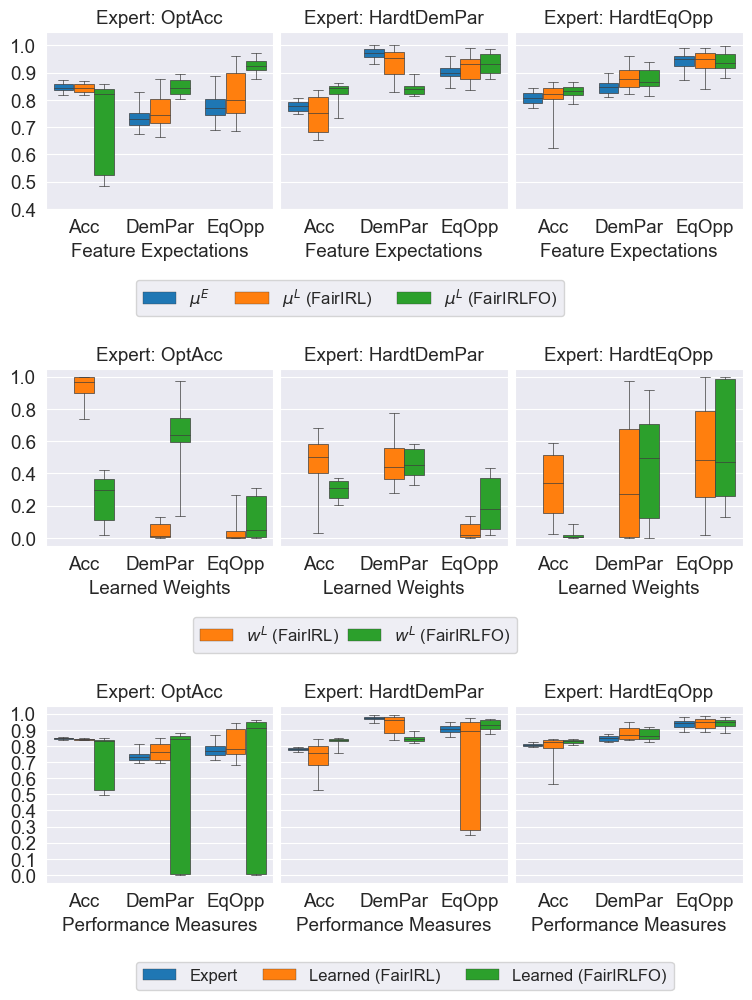

In [135]:
size_mult = 1.5
plt.rc("axes", titlesize=9 * size_mult)  # fontsize of the axes title
plt.rc("axes", labelsize=9 * size_mult)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=9 * size_mult)  # fontsize of the tick labels
plt.rc("ytick", labelsize=9 * size_mult)  # fontsize of the tick labels
plt.rc("ytick", labelsize=9 * size_mult)  # fontsize of the tick labels
plt.rc("legend", fontsize=8 * size_mult)  # legend fontsize
plt.rc("figure", titlesize=9 * size_mult)  # fontsize of the figure title

print("Experiment ID:", exp_info["EXPERIMENT_NAME"])

fig, axes, mu_dfs, w_dfs, perf_dfs = plot_results_source_domain_only(
    feat_objective_set_names=base_exp_info["FEAT_EXP_OBJECTIVE_NAMES"],
    perf_objective_set_names=base_exp_info["PERF_MEAS_OBJECTIVE_NAMES"],
    #     expert_algos=np.unique([exp['EXPERT_ALGO'] for exp in experiments]),
    expert_algos=["OptAcc", "HardtDemPar", "HardtEqOpp"],
    dataset=base_exp_info["DATASET"],
    mu_noise_factor=0.05,
    perf_noise_factor=0.01,
    w_noise_factor=0.01,
    mu_hue_order=["muE", "muL (FairIRL)", "muL (FairIRLFO)"],
    perf_hue_order=["muE", "muL (FairIRL)", "muL (FairIRLFO)"],
    w_hue_order=[None, "wL (FairIRL)", "wL (FairIRLFO)"],
    extra_skip_conditions=skip_by_name,
    min_exp_timestamp=min_exp_timestamp,
    min_mu_value=0.4,
    max_mu_value=1,
    min_w_value=0,
    mu_yticks=np.linspace(0, 1, 11).round(1),
    mu_ylim=(0.4, 1.05),
    mu_whis=[1, 99],
    w_yticks=np.linspace(0, 1, 6).round(1),
    w_ylim=(-0.05, 1.05),
    w_whis=[5, 95],
    perf_ylim=(-0.05, 1.05),
    perf_yticks=np.linspace(0, 1, 11).round(1),
    size_mult=size_mult,
)

# Compare results with target domain

Experiment ID: thesis_7
SOURCE DATASET: Boston
TARGET DATASET: COMPAS


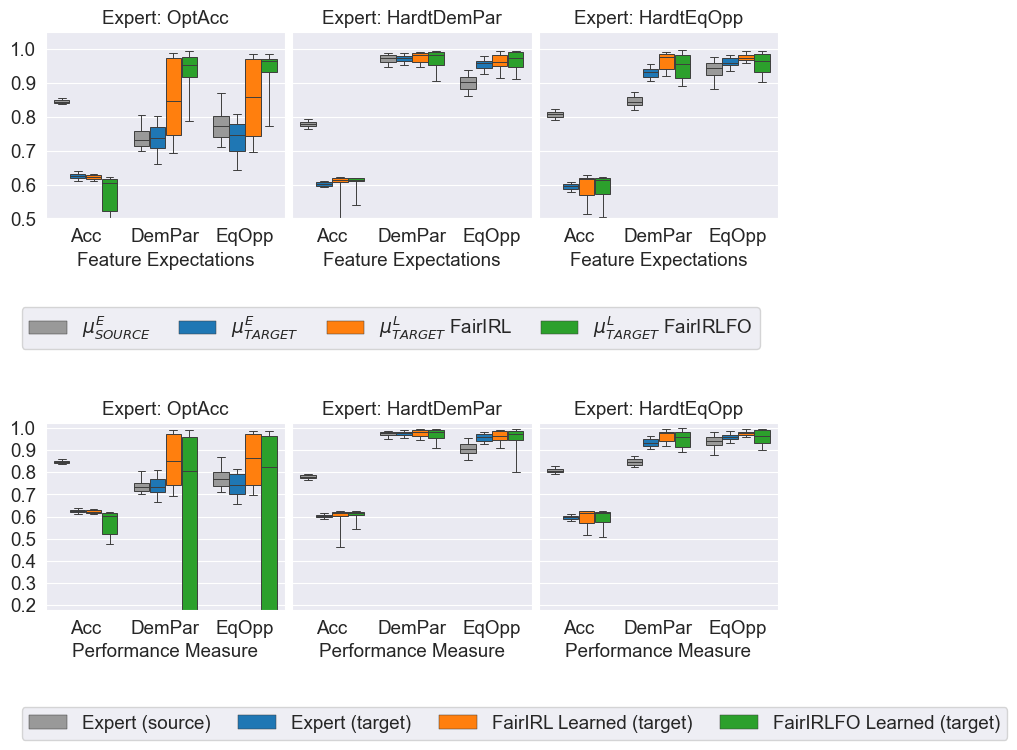

In [131]:
## plt.rc('axes', titlesize=11)     # fontsize of the axes title
size_mult = 1.5
plt.rc("axes", labelsize=9 * size_mult)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=9 * size_mult)  # fontsize of the tick labels
plt.rc("ytick", labelsize=9 * size_mult)  # fontsize of the tick labels
plt.rc("legend", fontsize=9 * size_mult)  # legend fontsize
plt.rc("figure", titlesize=9 * size_mult)  # fontsize of the figure title

print("Experiment ID:", exp_info["EXPERIMENT_NAME"])

result, mu_df, w_df, perf_df = plot_results_target_domain(
    feat_objective_set_names=base_exp_info["FEAT_EXP_OBJECTIVE_NAMES"],
    perf_objective_set_names=base_exp_info["PERF_MEAS_OBJECTIVE_NAMES"],
    #     expert_algos=np.unique([exp['EXPERT_ALGO'] for exp in experiments]),
    expert_algos=["OptAcc", "HardtDemPar", "HardtEqOpp"],
    source_dataset=base_exp_info["DATASET"],
    target_dataset=base_exp_info["TARGET_DATASET"],
    mu_noise_factor=0.001,
    extra_skip_conditions=skip_by_name,
    min_exp_timestamp=min_exp_timestamp,
    min_mu_value=0.4,
    mu_yticks=np.linspace(0, 1, 11).round(1),
    mu_ylim=(0.5, 1.05),
    mu_whis=[5, 95],
    perf_noise_factor=0.01,
    perf_hue_order=["muE", "muL (FairIRL)", "muL (FairIRLFO)"],
    perf_yticks=np.linspace(0.2, 1, 9).round(1),
    perf_ylim=(0.18, 1.02),
    size_mult=size_mult,
)

# Scratch

In [170]:
exp_info = dict(base_exp_info)
exp_info["FEAT_EXP_OBJECTIVE_NAMES"] = [
    "TPR_Z0",
    "TPR_Z1",
    #     'TNR_Z0', 'TNR_Z1',
    "FPR_Z0",
    "FPR_Z1",
    #     'FNR_Z0', 'FNR_Z1',
    #     'Acc',
    #     'DemPar',
    #     'EqOpp',
    #     'PredPar',
]
exp_info["RESTRICT_Y_ACTION"] = True

X, y, ft = generate_compas_dataset(20_000)
# X, y, ft = generate_adult_dataset(20_000)

# Initiate objectives
objectives = []
for obj_name in exp_info["FEAT_EXP_OBJECTIVE_NAMES"]:
    objectives.append(OBJ_LOOKUP_BY_NAME[obj_name]())
feat_obj_set = ObjectiveSet(objectives)
del objectives
# Reset the objective set since they get fitted in each trial run
feat_obj_set.reset()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)
del X, y


# Fit a classifier that predicts `y` from `X`.
clf = sklearn_clf_pipeline(
    feature_types=ft,
    clf_inst=RandomForestClassifier(),
)
clf.fit(X_train, y_train)

# Initiate variables needed to run IRL Loop
x_cols = ft["boolean"] + ft["categoric"] + ft["continuous"]
x_cols.remove("z")

# wi = [.2, .3, -.15, -.2]  # .598, .881, .906
# wi = [.195, .22, -.205, -.17]  # .608, .984, .994
wi = [0.2, 0.3, 0.15, 0.2]  # .598, .881, .906
# wi = [.9, .02, .02]


reward_weights = {obj.name: wi[j] for j, obj in enumerate(feat_obj_set.objectives)}

test_df = X_test.copy()
test_df["y"] = y_test
# test_df = X_train.copy()
# test_df['y'] = y_train
# test_df['y'] = clf.predict(X_test)

clf_pol = compute_optimal_policy(
    clf_df=test_df,  # NOT the dataset used to train the C_{Y_Z,X} clf
    clf=clf,
    x_cols=x_cols,
    obj_set=feat_obj_set,
    reward_weights=reward_weights,
    skip_error_terms=True,
    method=exp_info["METHOD"],
    min_freq_fill_pct=exp_info["MIN_FREQ_FILL_PCT"],
)

demo = generate_demo(clf_pol, X_train, y_train, can_observe_y=False)
muj = feat_obj_set.compute_demo_feature_exp(demo)
print(f"\t\t muL = {np.round(muj, 3)}")


print("Acc", AccuracyObjective().compute_feat_exp(demo).round(3))
print("DemPar", DemographicParityObjective().compute_feat_exp(demo).round(3))
print("EqOpp", EqualOpportunityObjective().compute_feat_exp(demo).round(3))

display(demo.groupby(["z", "y"])[["yhat"]].agg(["count", "mean", "sum"]))
display(demo.groupby(["z"])[["yhat"]].agg(["count", "mean", "sum"]))

		 muL = [0.748 0.776 0.503 0.396]
Acc 0.605
DemPar 0.947
EqOpp 0.972


yhat                  
    count      mean     sum
z y                        
0 0  4608  0.496745  2289.0
  1  4768  0.748112  3567.0
1 0  2650  0.604151  1601.0
  1  1970  0.776142  1529.0

yhat                  
  count      mean     sum
z                        
0  9376  0.624573  5856.0
1  4620  0.677489  3130.0

# HW Scratch

In [11]:
from math import comb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

### Problem 1

In [28]:
def expected_4_cliques(n, p):
    return comb(n, 4) * p**6

In [45]:
def thresh_4_clique(n):
    return comb(n, 4) ** (-(1 / 6))

In [120]:
expected_4_cliques(int(1e15), p=1e-9)

41666.66666666643

100000 0.0007883266647717149
1000000 0.0001698383027949114
10000000 3.659052019222436e-05


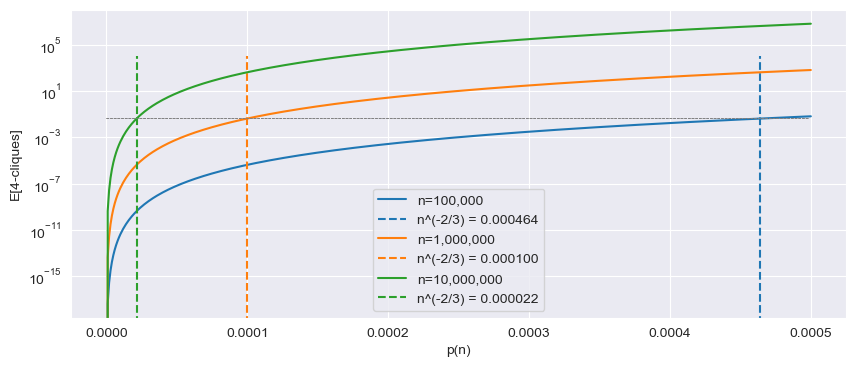

In [237]:
sns.set_style("darkgrid")
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
cp = sns.color_palette()

for i, n in enumerate([100_000, 1_000_000, 10_000_000]):
    x = np.linspace(0, 0.0005, 501)
    y = [expected_4_cliques(n, p) for p in x]
    ax.plot(x, y, label=f"n={n:,}", c=cp[i])
    ax.set_xlabel("p(n)")
    ax.set_ylabel("E[4-cliques]")
    print(n, thresh_4_clique(n))

    thresh = n ** (-2 / 3)
    threshx = [thresh for _ in range(10)]
    threshy = np.linspace(0, 1e4, 10)
    ax.plot(threshx, threshy, ls="--", label=f"n^(-2/3) = {thresh:.6f}", c=cp[i])

    x2 = np.linspace(0, 0.95 * ax.get_xlim()[1], 2)
    y2 = 0.05 * np.ones(2)
    ax.plot(x2, y2, ls="--", lw=0.5, c="gray")

# ax.set_xscale('log')
ax.set_yscale("log")
ax.legend()
pass

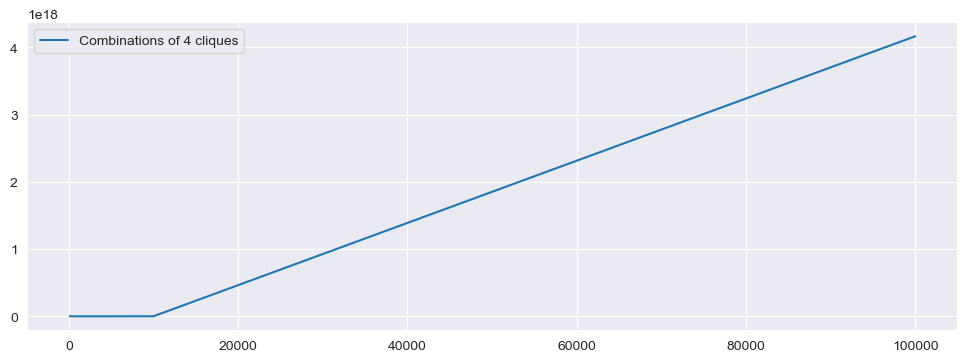

In [95]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
x1 = [100, 1_000, 10_000, 100_000]
y1 = [comb(n, 4) for n in x1]
x2 = np.linspace(0, 1, 101)
y2 = [p**6 for p in x2]
ax.plot(x1, y1, label="Combinations of 4 cliques")
# ax.plot(x2, y2, label='p^6(n)')
ax.legend()

In [42]:
comb(1000, 4) * 2 ** (-(comb(4, 2)))

647142574.21875

In [43]:
2 ** (-(comb(4, 2)))

0.015625

### Problem 4

In [157]:
def prob_vertex_has_deg_k(n, k, p):
    return comb(n, k) * (p**k) * (1 - p) ** (n - k)

In [197]:
k_range = [
    3,
    int(np.log(n)),
    int(np.sqrt(n)),
    int(n - 1),
]
n = 1_000
d = 100
p = d / n

for k in k_range:
    output = n * comb(n, k) * (p**k)
    print(k, ":", output)

3 : 166167000.00000003
6 : 1368173298991.5005
31 : 7.602322407769473e+30
999 : 0.0
